<a href="https://colab.research.google.com/github/sophgutie/hello-github/blob/main/WorldBank_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [5]:
df = pd.read_excel("GFDDData.xlsx")

df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,Global Financial Development Database


In [8]:
excel = pd.ExcelFile("GFDDData.xlsx")

print(excel.sheet_names)

['Summary', 'Metadata', 'Data - August 2022', 'Metadata - 2021', 'Data - November 2021']


In [11]:
df = pd.read_excel(
    "GFDDData.xlsx",
    sheet_name="Data - August 2022"
)

df.head()

,iso3,iso2,imfn,country,region,income,year,ai01,ai02,ai03,ai04,ai05,ai06,ai07,ai08,ai09,ai10,ai11,ai12,ai13,ai14,ai15,ai16,ai17,ai18,ai19,ai20,ai21,ai22,ai23,ai24,ai25,ai26,ai27,ai28,ai29,ai30,ai31,ai32,ai33,...,dm16,ei01,ei02,ei03,ei04,ei05,ei06,ei07,ei08,ei09,ei10,em01,si01,si02,si03,si04,si05,si06,si07,sm01,oi01,oi02,oi06,oi07,oi08,oi09,oi10,oi11,oi12,oi13,oi14,oi15,oi16,oi16a,oi17,oi18,oi19,oi20a,om01,om02
0,ABW,AW,314,Aruba,Latin America & Caribbean,High income,1960,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,AW,314,Aruba,Latin America & Caribbean,High income,1961,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,AW,314,Aruba,Latin America & Caribbean,High income,1962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,AW,314,Aruba,Latin America & Caribbean,High income,1963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,AW,314,Aruba,Latin America & Caribbean,High income,1964,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13268 entries, 0 to 13267
Columns: 115 entries, iso3 to om02
dtypes: float64(108), int64(2), object(5)
memory usage: 11.6+ MB


In [13]:
print(df.columns.tolist())

['iso3', 'iso2', 'imfn', 'country', 'region', 'income', 'year', 'ai01', 'ai02', 'ai03', 'ai04', 'ai05', 'ai06', 'ai07', 'ai08', 'ai09', 'ai10', 'ai11', 'ai12', 'ai13', 'ai14', 'ai15', 'ai16', 'ai17', 'ai18', 'ai19', 'ai20', 'ai21', 'ai22', 'ai23', 'ai24', 'ai25', 'ai26', 'ai27', 'ai28', 'ai29', 'ai30', 'ai31', 'ai32', 'ai33', 'ai34', 'ai35', 'ai36', 'am01', 'am02', 'am03', 'di01', 'di02', 'di03', 'di04', 'di05', 'di06', 'di07', 'di08', 'di09', 'di10', 'di11', 'di12', 'di13', 'di14', 'dm01', 'dm02', 'dm03', 'dm04', 'dm05', 'dm06', 'dm07', 'dm08', 'dm09', 'dm10', 'dm11', 'dm12', 'dm13', 'dm14', 'dm15', 'dm16', 'ei01', 'ei02', 'ei03', 'ei04', 'ei05', 'ei06', 'ei07', 'ei08', 'ei09', 'ei10', 'em01', 'si01', 'si02', 'si03', 'si04', 'si05', 'si06', 'si07', 'sm01', 'oi01', 'oi02', 'oi06', 'oi07', 'oi08', 'oi09', 'oi10', 'oi11', 'oi12', 'oi13', 'oi14', 'oi15', 'oi16', 'oi16a', 'oi17', 'oi18', 'oi19', 'oi20a', 'om01', 'om02']


In [14]:
metadata = pd.read_excel(
    "GFDDData.xlsx",
    sheet_name="Metadata"
)

metadata.head(20)

,Topic,Indicator Code,Indicator Name,Short Definition,Long Definition,Coverage,Sources,Comment
0,Access,GFDD.AI.01,"Bank accounts per 1,000 adults",Number of depositors with commercial banks per...,"For each country calculated as: 1,000*reported...",2004-2021,"Financial Access Survey (FAS), International M...",NaN
1,Access,GFDD.AI.02,"Bank branches per 100,000 adults","Number of commercial bank branches per 100,000...","For each country calculated as: 100,000*report...",2004-2021,"Financial Access Survey (FAS), International M...",NaN
2,Access,GFDD.AI.03,Firms with a bank loan or line of credit (%),Percentage of firms in the formal sector with ...,Percentage of firms in the formal sector with ...,2006-2021,"Enterprise Surveys, World Bank",NaN
3,Access,GFDD.AI.04,Small firms with a bank loan or line of credit...,Percentage of small firms (5-19 workers) in th...,Percentage of small firms (5-19 workers) in th...,2006-2021,"Enterprise Surveys, World Bank",NaN
4,Access,GFDD.AI.05,Financial institution account (% age 15+),The percentage of respondents who report havin...,The percentage of respondents who report havin...,"2011, 2014, 2017, 2021",Global Financial Inclusion (Global Findex) Dat...,Definitions adapted (Global Findex)
5,Access,GFDD.AI.06,Saved at a financial institution (% age 15+),The percentage of respondents who report savin...,The percentage of respondents who report savin...,"2011, 2014, 2017, 2021",Global Financial Inclusion (Global Findex) Dat...,Definitions adapted (Global Findex)
6,Access,GFDD.AI.07,Borrowed from a formal financial institution (...,The percentage of respondents who report borro...,The percentage of respondents who report borro...,"2011, 2014, 2017, 2021",Global Financial Inclusion (Global Findex) Dat...,Indicator name and definitions adapted (Global...
7,Access,GFDD.AI.08,"Borrowed to start, operate, or expand a farm o...",The percentage of respondents who report borro...,The percentage of respondents who report borro...,"2014, 2017",Global Financial Inclusion (Global Findex) Dat...,Definitions adapted (Global Findex)
8,Access,GFDD.AI.09,Received government transfer: into a financial...,The percentage of respondents who report perso...,The percentage of respondents who report perso...,"2014, 2017, 2021",Global Financial Inclusion (Global Findex) Dat...,Definitions adapted (Global Findex)
9,Access,GFDD.AI.10,Received domestic remittances: into an account...,The percentage of respondents who report perso...,The percentage of respondents who report perso...,"2014, 2017, 2021",Global Financial Inclusion (Global Findex) Dat...,Indicator name and definitions adapted (Global...


In [15]:
metadata.columns

Index(['Topic', 'Indicator Code', 'Indicator Name', 'Short Definition',
       'Long Definition', 'Coverage', 'Sources', 'Comment'],
      dtype='object')

In [16]:
metadata[["Indicator Code", "Indicator Name"]]

,Indicator Code,Indicator Name
0,GFDD.AI.01,"Bank accounts per 1,000 adults"
1,GFDD.AI.02,"Bank branches per 100,000 adults"
2,GFDD.AI.03,Firms with a bank loan or line of credit (%)
3,GFDD.AI.04,Small firms with a bank loan or line of credit...
4,GFDD.AI.05,Financial institution account (% age 15+)
...,...,...
107,GFDD.OI.18,Total factoring volume to GDP (%)
108,GFDD.OI.19,"Banking crisis dummy (1=banking crisis, 0=none)"
109,GFDD.OI.20a,Government bank assets among total bank assets...
110,GFDD.OM.01,"Number of listed companies per 1,000,000 people"


In [17]:
metadata[metadata["Indicator Name"].str.contains("Domestic Credit", case=False, na=False)]

,Topic,Indicator Code,Indicator Name,Short Definition,Long Definition,Coverage,Sources,Comment
53,Depth,GFDD.DI.14,Domestic credit to private sector (% of GDP),Domestic credit to private sector refers to fi...,Domestic credit to private sector refers to fi...,1960-2020,"World Development Indicators (WDI), World Bank",NaN


In [18]:
metadata[metadata["Indicator Name"].str.contains("Bank Branch", case=False, na=False)]

,Topic,Indicator Code,Indicator Name,Short Definition,Long Definition,Coverage,Sources,Comment
1,Access,GFDD.AI.02,"Bank branches per 100,000 adults","Number of commercial bank branches per 100,000...","For each country calculated as: 100,000*report...",2004-2021,"Financial Access Survey (FAS), International M...",NaN


In [19]:
metadata[metadata["Indicator Name"].str.contains("Financial Institutions Index", case=False, na=False)]

,Topic,Indicator Code,Indicator Name,Short Definition,Long Definition,Coverage,Sources,Comment


In [20]:
metadata[metadata["Indicator Name"].str.contains("Financial Markets Index", case=False, na=False)]

,Topic,Indicator Code,Indicator Name,Short Definition,Long Definition,Coverage,Sources,Comment


In [21]:
df_clean = df[[
    "country",
    "region",
    "income",
    "year",
    "di14",
    "ai02"
]].copy()

df_clean.columns = [
    "Country",
    "Region",
    "Income",
    "Year",
    "DomesticCredit",
    "BankBranches"
]

df_clean.head()

,Country,Region,Income,Year,DomesticCredit,BankBranches
0,Aruba,Latin America & Caribbean,High income,1960,NaN,NaN
1,Aruba,Latin America & Caribbean,High income,1961,NaN,NaN
2,Aruba,Latin America & Caribbean,High income,1962,NaN,NaN
3,Aruba,Latin America & Caribbean,High income,1963,NaN,NaN
4,Aruba,Latin America & Caribbean,High income,1964,NaN,NaN


In [22]:
df_clean.isnull().sum()

,0
Country,0
Region,0
Income,0
Year,0
DomesticCredit,6560
BankBranches,10260


In [23]:
df_clean = df_clean.dropna()

df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2666 entries, 51 to 13266
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         2666 non-null   object 
 1   Region          2666 non-null   object 
 2   Income          2666 non-null   object 
 3   Year            2666 non-null   int64  
 4   DomesticCredit  2666 non-null   float64
 5   BankBranches    2666 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 145.8+ KB


In [24]:
df_clean.describe()

,Year,DomesticCredit,BankBranches
count,2666.000000,2666.000000,2666.000000
mean,2012.179670,53.023177,30.640287
std,4.725681,44.761532,121.143095
min,2004.000000,0.186170,0.136835
25%,2008.000000,19.887375,5.109581
50%,2012.000000,40.064050,13.801030
75%,2016.000000,72.573425,24.897254
max,2020.000000,304.575000,1784.200100


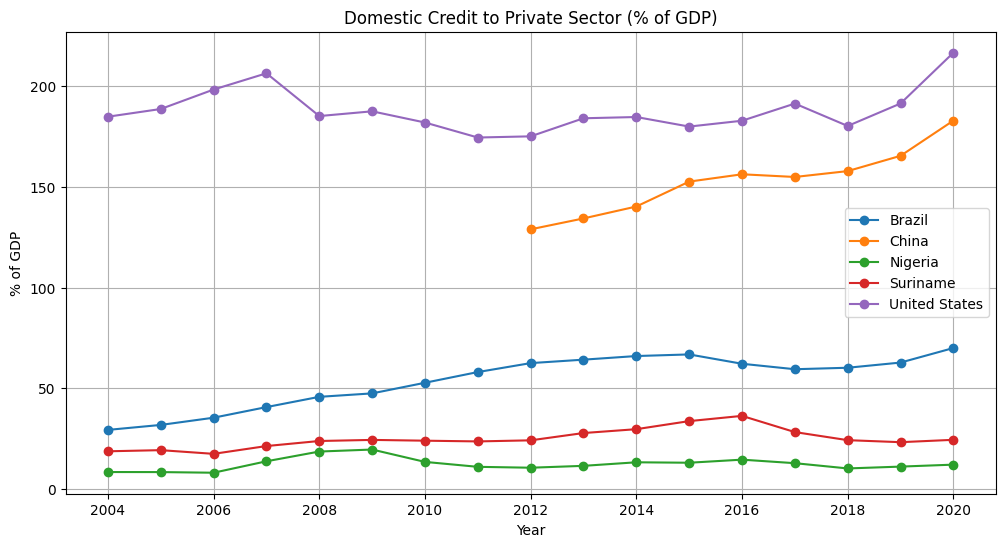

In [25]:
countries = [
    "Brazil",
    "China",
    "Nigeria",
    "Suriname",
    "United States"
]

plot_df = df_clean[df_clean["Country"].isin(countries)]

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for country in countries:
    temp = plot_df[plot_df["Country"] == country]
    plt.plot(
        temp["Year"],
        temp["DomesticCredit"],
        marker="o",
        label=country
    )

plt.title("Domestic Credit to Private Sector (% of GDP)")
plt.xlabel("Year")
plt.ylabel("% of GDP")
plt.legend()
plt.grid(True)

plt.show()

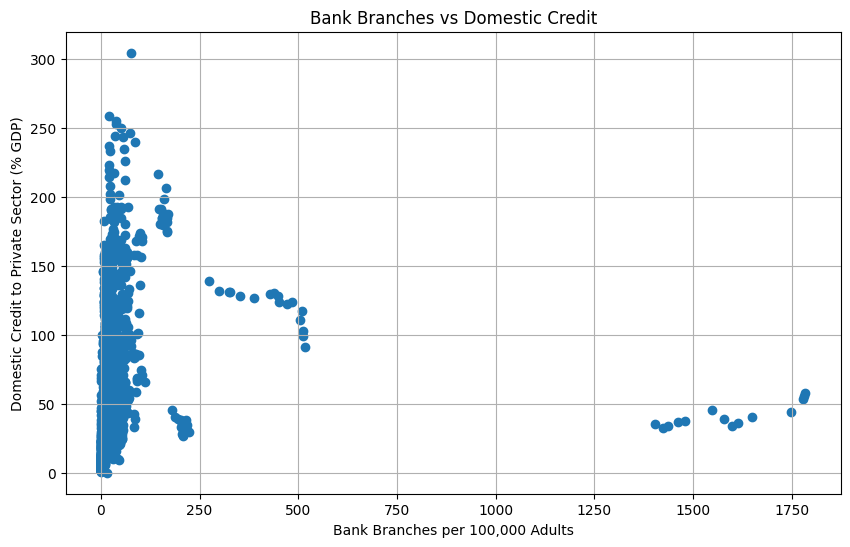

In [27]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_clean["BankBranches"],
    df_clean["DomesticCredit"]
)

plt.xlabel("Bank Branches per 100,000 Adults")
plt.ylabel("Domestic Credit to Private Sector (% GDP)")
plt.title("Bank Branches vs Domestic Credit")

plt.grid(True)

plt.show()

In [29]:
us = df_clean[df_clean["Country"] == "United States"].copy()

us.head()

,Country,Region,Income,Year,DomesticCredit,BankBranches
12444,United States,North America,High income,2004,184.806,153.87141
12445,United States,North America,High income,2005,188.633,157.06532
12446,United States,North America,High income,2006,198.284,160.39660
12447,United States,North America,High income,2007,206.351,164.64507
12448,United States,North America,High income,2008,185.126,166.93049


In [30]:
us.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17 entries, 12444 to 12460
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Country         17 non-null     object 
 1   Region          17 non-null     object 
 2   Income          17 non-null     object 
 3   Year            17 non-null     int64  
 4   DomesticCredit  17 non-null     float64
 5   BankBranches    17 non-null     float64
dtypes: float64(2), int64(1), object(3)
memory usage: 952.0+ bytes


In [31]:
us = us.sort_values("Year")

us.head()

,Country,Region,Income,Year,DomesticCredit,BankBranches
12444,United States,North America,High income,2004,184.806,153.87141
12445,United States,North America,High income,2005,188.633,157.06532
12446,United States,North America,High income,2006,198.284,160.39660
12447,United States,North America,High income,2007,206.351,164.64507
12448,United States,North America,High income,2008,185.126,166.93049


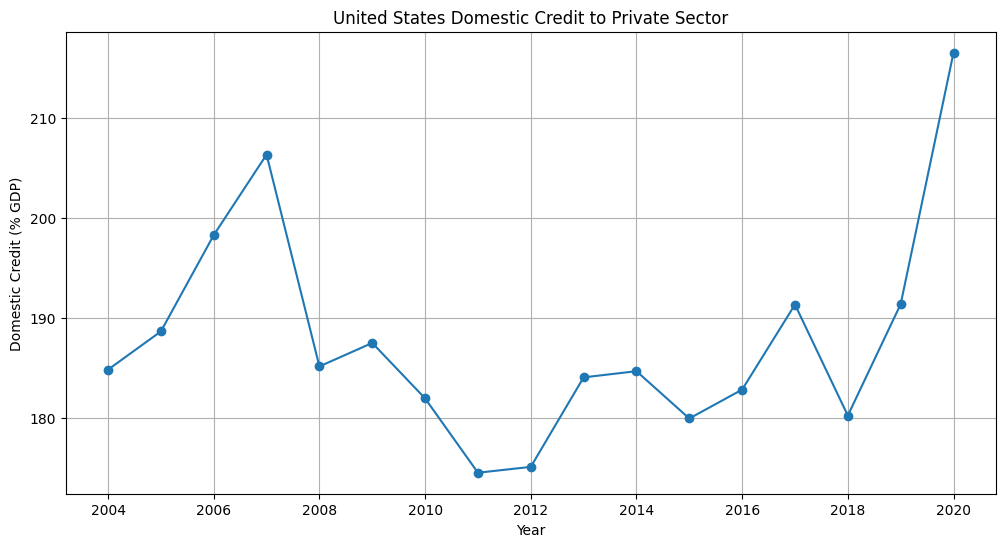

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    us["Year"],
    us["DomesticCredit"],
    marker="o"
)

plt.title("United States Domestic Credit to Private Sector")

plt.xlabel("Year")

plt.ylabel("Domestic Credit (% GDP)")

plt.grid(True)

plt.show()

In [33]:
X = us[["Year"]]

y = us["DomesticCredit"]

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [35]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [36]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("Linear Regression Results")
print("-------------------------")
print("R² =", r2_score(y_test, pred_lr))
print("MAE =", mean_absolute_error(y_test, pred_lr))
print("RMSE =", mean_squared_error(y_test, pred_lr) ** 0.5)

Linear Regression Results
-------------------------
R² = 0.32717754042304115
MAE = 1.6892292229729975
RMSE = 1.9310576654922444


In [37]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [38]:
print("Random Forest Results")
print("---------------------")
print("R² =", r2_score(y_test, pred_rf))
print("MAE =", mean_absolute_error(y_test, pred_rf))
print("RMSE =", mean_squared_error(y_test, pred_rf) ** 0.5)

Random Forest Results
---------------------
R² = -12.454516610321454
MAE = 6.809544999999886
RMSE = 8.635332257930095


In [39]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Random Forest"
    ],
    "R2":[
        r2_score(y_test, pred_lr),
        r2_score(y_test, pred_rf)
    ],
    "MAE":[
        mean_absolute_error(y_test, pred_lr),
        mean_absolute_error(y_test, pred_rf)
    ],
    "RMSE":[
        mean_squared_error(y_test, pred_lr) ** 0.5,
        mean_squared_error(y_test, pred_rf) ** 0.5
    ]
})

results

,Model,R2,MAE,RMSE
0,Linear Regression,0.327178,1.689229,1.931058
1,Random Forest,-12.454517,6.809545,8.635332


In [41]:
future = pd.DataFrame({
    "Year":[2022,2023,2024,2025,2026,2027,2028,2029,2030]
})

lr.fit(X,y)

future["PredictedDomesticCredit"] = lr.predict(future)

future

,Year,PredictedDomesticCredit
0,2022,189.599848
1,2023,189.777615
2,2024,189.955382
3,2025,190.133150
4,2026,190.310917
5,2027,190.488684
6,2028,190.666451
7,2029,190.844218
8,2030,191.021985


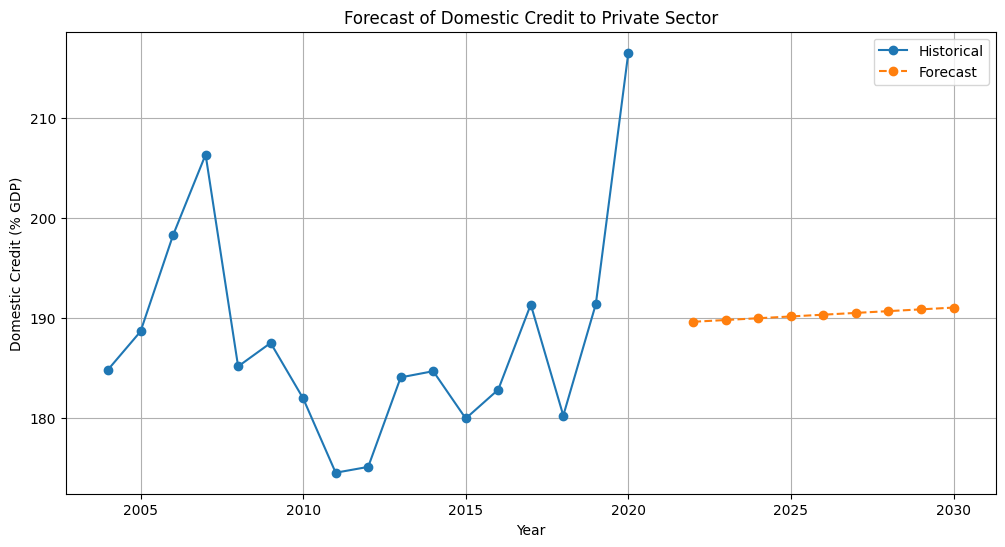

In [42]:
plt.figure(figsize=(12,6))

plt.plot(
    us["Year"],
    us["DomesticCredit"],
    marker="o",
    label="Historical"
)

plt.plot(
    future["Year"],
    future["PredictedDomesticCredit"],
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Forecast of Domestic Credit to Private Sector")

plt.xlabel("Year")

plt.ylabel("Domestic Credit (% GDP)")

plt.legend()

plt.grid(True)

plt.show()